# Instalação

In [1]:
# Instala o uv (caso não esteja instalado no ambiente base)
%pip install uv

# Cria o ambiente virtual (.venv) no diretório atual e força a substituição se já existir
!uv venv --clear 

# Instala as bibliotecas necessárias
!uv pip install pandas numpy matplotlib scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Using CPython 3.13.12 interpreter at: c:\Users\User\AppData\Local\Programs\Python\Python313\python.exe
Creating virtual environment at: .venv
Activate with: .venv\Scripts\activate
Resolved 19 packages in 581ms
Installed 19 packages in 5.59s
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.62.1
 + imbalanced-learn==0.14.1
 + joblib==1.5.3
 + kiwisolver==1.5.0
 + matplotlib==3.10.9
 + numpy==2.4.4
 + packaging==26.2
 + pandas==3.0.2
 + pillow==12.2.0
 + pyparsing==3.3.2
 + python-dateutil==2.9.0.post0
 + scikit-learn==1.8.0
 + scipy==1.17.1
 + six==1.17.0
 + sklearn-compat==0.1.5
 + threadpoolctl==3.6.0
 + tzdata==2026.2


In [2]:
!uv pip install ipykernel

Resolved 28 packages in 323ms
Installed 25 packages in 24.46s
 + asttokens==3.0.1
 + colorama==0.4.6
 + comm==0.2.3
 + debugpy==1.8.20
 + decorator==5.2.1
 + executing==2.2.1
 + ipykernel==7.2.0
 + ipython==9.13.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.20.0
 + jupyter-client==8.8.0
 + jupyter-core==5.9.1
 + matplotlib-inline==0.2.1
 + nest-asyncio==1.6.0
 + parso==0.8.7
 + platformdirs==4.9.6
 + prompt-toolkit==3.0.52
 + psutil==7.2.2
 + pure-eval==0.2.3
 + pygments==2.20.0
 + pyzmq==27.1.0
 + stack-data==0.6.3
 + tornado==6.5.5
 + traitlets==5.14.3
 + wcwidth==0.7.0


In [3]:
!uv run python -m ipykernel install --user --name trabalho-carprice_assignment --display-name "carprice_assingnment(uv)"


Installed kernelspec trabalho-carprice_assignment in C:\Users\User\AppData\Roaming\jupyter\kernels\trabalho-carprice_assignment


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.metrics import classification_report

# introdução

`Nome: Gabriel Dário Gouveia`

`RA:4201062`

`Dataset utilizado: CarPrice_Prediction`

dowload do dataset: https://www.kaggle.com/datasets/afsanashaikh1753/carprice-prediction?resource=download

O objetivo deste projeto é construir um modelo de Machine Learning capaz de prever o preço de carros com base em características como potência, tamanho do motor, consumo de combustível e marca.

Para isso, foi utilizado o dataset CarPrice_Assignment.csv, contendo informações técnicas e comerciais de diferentes veículos.

O projeto envolve:
- análise exploratória dos dados;
- limpeza e tratamento;
- transformação de variáveis;
- treinamento de modelos;
- avaliação de desempenho.

O dataset utilizado contém informações sobre diferentes modelos de carros e seus respectivos preços.

Cada linha representa um veículo e cada coluna representa uma característica do carro.

O conjunto de dados possui variáveis numéricas e categóricas relacionadas ao desempenho, consumo, dimensões e especificações técnicas dos veículos.

A variável target escolhida foi `price`, pois o objetivo do projeto é prever o preço dos veículos.
Todas as demais variáveis serão utilizadas como features para treinar o modelo.

# Análise Exploratória (EDA)

In [2]:
df = pd.read_csv('CarPrice_Assignment.csv')
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


O método `df.info()` foi utilizado para analisar:
- quantidade de linhas e colunas;
- tipos de dados;
- existência de valores nulos.

Essa etapa é importante para entender a estrutura do dataset antes da limpeza.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

**Dicionário de Dados (Significado das Features):**

*   **`0. Rank`**: id da tabela (será removido)
*   **`1. car_ID`**: identificador único de cada carro (será removido, não agrega valor preditivo)
*   **`2. symboling`**: índice de risco do carro (valores mais altos indicam maior risco associado ao seguro)
*   **`3. CarName`**: nome/modelo do carro (pode ser simplificado para extrair apenas a marca)
*   **`4. fueltype`**: tipo de combustível (gasolina ou diesel)
*   **`5. aspiration`**: tipo de aspiração do motor (stander ou turbo)
*   **`6. doornumber`**: número de portas do carro
*   **`7. carbody`**: tipo de carroceria (sedan, hatchback, convertible, etc.)
*   **`8. drivewheel`**: tipo de tração (dianteira - fwd, traseira - rwd, integral - 4wd)
*   **`9. enginelocation`**: localização do motor (dianteiro ou traseiro)
*   **`10. wheelbase`**: distância entre os eixos (impacta estabilidade e espaço interno)
*   **`11. carlength`**: comprimento do carro
*   **`12. carwidth`**: largura do carro
*   **`13. carheight`**: altura do carro
*   **`14. curbweight`**: peso do carro sem passageiros ou carga
*   **`15. enginetype`**: tipo de motor (ohc, dohc, etc.)
*   **`16. cylindernumber`**: número de cilindros do motor
*   **`17. enginesize`**: tamanho do motor (relacionado à potência)
*   **`18. fuelsystem`**: sistema de combustível (mpfi, 2bbl, etc.)
*   **`19. boreratio`**: diâmetro do cilindro do motor
*   **`20. stroke`**: curso do pistão
*   **`21. compressionratio`**: taxa de compressão do motor
*   **`22. horsepower`**: potência do motor (em cavalos)
*   **`23. peakrpm`**: rotações por minuto em que o motor atinge potência máxima
*   **`24. citympg`**: consumo de combustível na cidade
*   **`25. highwaympg`**: consumo de combustível na estrada
*   **`26. price`**: preço do carro (variável alvo - target)

O método `describe()` foi utilizado para obter estatísticas descritivas das variáveis numéricas, como:
- média;
- desvio padrão;
- valores mínimos e máximos;
- quartis.

Essas informações ajudam na identificação de possíveis outliers e distribuições anormais.

In [4]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


Os histogramas foram utilizados para visualizar a distribuição das variáveis numéricas.

Essa análise permite identificar:
- assimetria;
- concentração de valores;
- possíveis outliers;
- necessidade de transformações estatísticas.

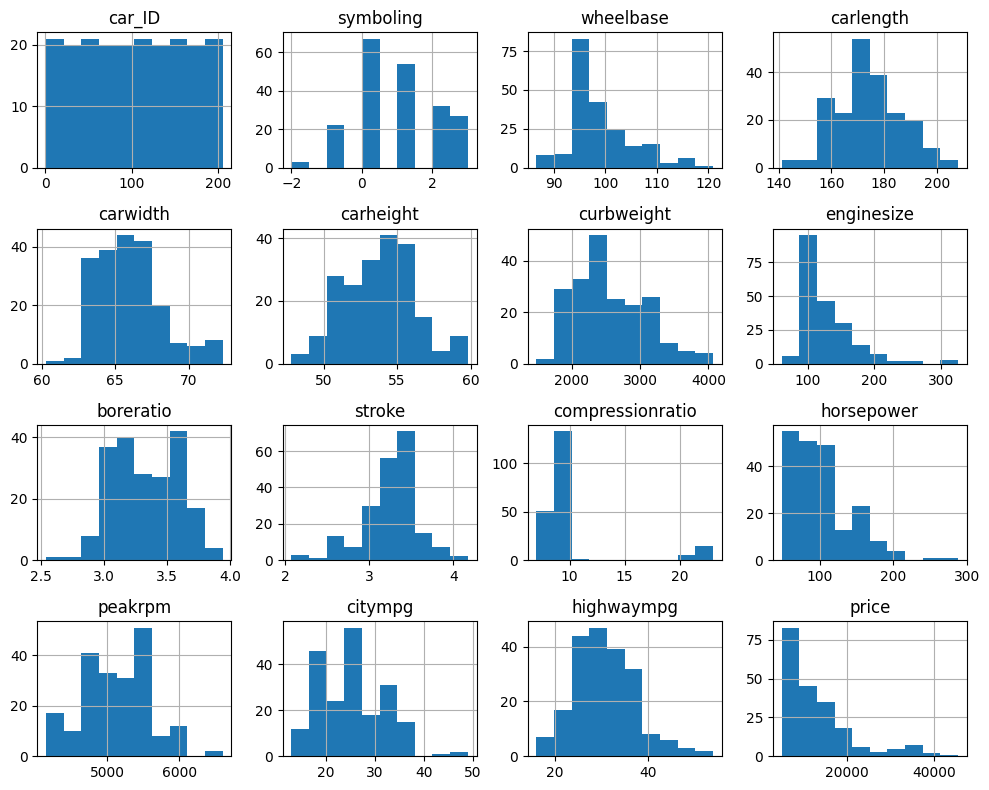

In [5]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

Como pode ser observado, as colunas `wheelbase`, `horsepower`, `enginesize` e `price` possuem uma calda longa, portanto
deverão receber tratamento nas proximas etapas

# Limpeza

O método `.drop_duplicates()` revome linhas duplicadas, pórem nesse dataset não possui nenhuma, como é informado pelo proprio comando

In [3]:
df = df.drop_duplicates() 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

A verificação de valores nulos foi realizada para identificar possíveis dados faltantes que poderiam prejudicar o treinamento do modelo.

Como pode ser visto, não possui nenhum valor nulo, o que facilita o processo de tratamento do dataset 

In [4]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

A coluna `CarName` contém o nome completo dos veículos.

Foi criada uma nova coluna chamada `brand`, contendo apenas a marca do carro.

Essa decisão foi tomada porque a marca possui forte influência no preço do veículo, principalmente em carros considerados de luxo.

Manter apenas a marca reduz a dimensionalidade dos dados e evita excesso de categorias desnecessárias, alem de aumentar a precisão do modelo

In [ ]:
df['brand'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())

Algumas colunas foram removidas por não agregarem valor preditivo ao modelo.

- `car_ID`: apenas identificador único;
- `CarName`: substituída pela coluna `brand`;
- `enginelocation`: removida devido à ter apenas duas variaçôes, front e rear(motor na frente ou atras do veiculo) e por ter forte associação com valores extremos de horsepower, ao tratar o horsepower, por consequencia, todas as linhas com valor "rear" serão removidoas, tornando a coluna "enginelocation inutil, por ter apenas uma unica variação apartir de então

A remoção dessas colunas ajuda a reduzir ruído e complexidade no modelo.

In [ ]:
colunas_para_remover = ['car_ID', 'CarName', 'enginelocation']
df = df.drop(columns=colunas_para_remover, errors='ignore')

# Transformações Estatísticas

Foi aplicada transformação logarítmica nas variáveis `price`, `enginesize` e `horsepower`.

Essa técnica ajuda a:
- reduzir assimetria;
- diminuir impacto de outliers;
- aproximar a distribuição de uma distribuição normal.

Isso pode melhorar o desempenho de algoritmos de Machine Learning.

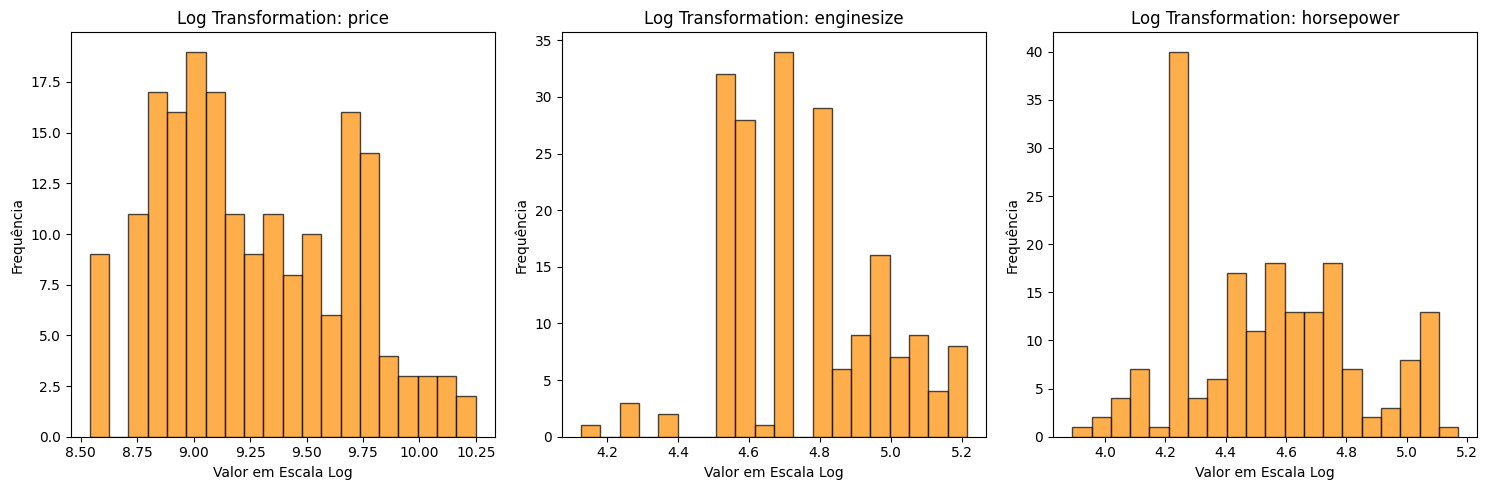

Dados de carros após o Log (primeiras linhas):
      price  enginesize  horsepower
0  9.510149    4.875197    4.718499
1  9.711176    4.875197    4.718499
2  9.711176    5.030438    5.043425
3  9.543306    4.700480    4.634729
4  9.767152    4.919981    4.753590


In [ ]:
df_log = df.copy()
colunas_carros = ['price', 'enginesize', 'horsepower']


# 2. Aplicar o logaritmo (usamos log1p por segurança, como no seu exemplo)
for col in colunas_carros:
    df_log[col] = np.log1p(df[col])

# 3. Visualizar como a distribuição mudou (usando Matplotlib puro)
plt.figure(figsize=(15, 5))

for i, col in enumerate(colunas_carros):
    plt.subplot(1, 3, i+1)
    plt.hist(df_log[col], bins=20, color='darkorange', edgecolor='black', alpha=0.7)
    plt.title(f"Log Transformation: {col}")
    plt.xlabel("Valor em Escala Log")
    plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

print("Dados de carros após o Log (primeiras linhas):")
print(df_log[colunas_carros].head())

# iqr

Existem 3 colunas que estão com caldas muito longas, horsepower, enginesize e wheelbase então sera aplicado o iqr
Price tambem possui calda longa, porém aplicar o iqr no target não é uma boa ideia, ja que o modelo pode ficar com poucos exemplos
da coluna que mais importa

In [11]:
# 1. Definir as colunas alvo
cols = ['horsepower', 'enginesize', 'wheelbase']

# 2. Calcular os Quartis e o IQR (retorna uma série para cada coluna)
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

# 3. Definir os limites de corte
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("--- Limites Calculados ---")
for c in cols:
    print(f"{c}: Inferior {lower[c]:.2f} | Superior {upper[c]:.2f}")

print(f"\nTamanho original: {len(df)}")

# 4. Identificar e Filtrar (A parte que dava erro)
# Usamos o método .all(axis=1) para garantir que a linha só fique se 
# TODAS as colunas selecionadas estiverem dentro dos limites.
mascara = ((df[cols] >= lower) & (df[cols] <= upper)).all(axis=1)

# Identificar outliers para o print (opcional)
outliers_count = len(df) - mascara.sum()
print(f"Quantidade de linhas com outliers removidas: {outliers_count}")

# 5. Filtrar o DataFrame
df = df[mascara].copy()

# 6. Resetar o índice 
df = df.reset_index(drop=True)

print(f"Novo tamanho: {len(df)}")

--- Limites Calculados ---
horsepower: Inferior 4.00 | Superior 180.00
enginesize: Inferior 41.50 | Superior 189.50
wheelbase: Inferior 85.65 | Superior 109.25

Tamanho original: 183
Quantidade de linhas com outliers removidas: 0
Novo tamanho: 183


# standerscaler

Nesta etapa foi utilizada a técnica de padronização dos dados com o `StandardScaler`.

A padronização transforma as variáveis numéricas para que todas fiquem na mesma escala, com:
- média igual a 0;
- desvio padrão igual a 1.

Esse processo é importante porque algumas variáveis possuem valores muito maiores que outras, o que pode influenciar negativamente o desempenho do modelo.

Ao padronizar os dados, o algoritmo consegue tratar todas as variáveis de forma mais equilibrada, melhorando a estabilidade e a performance do treinamento.

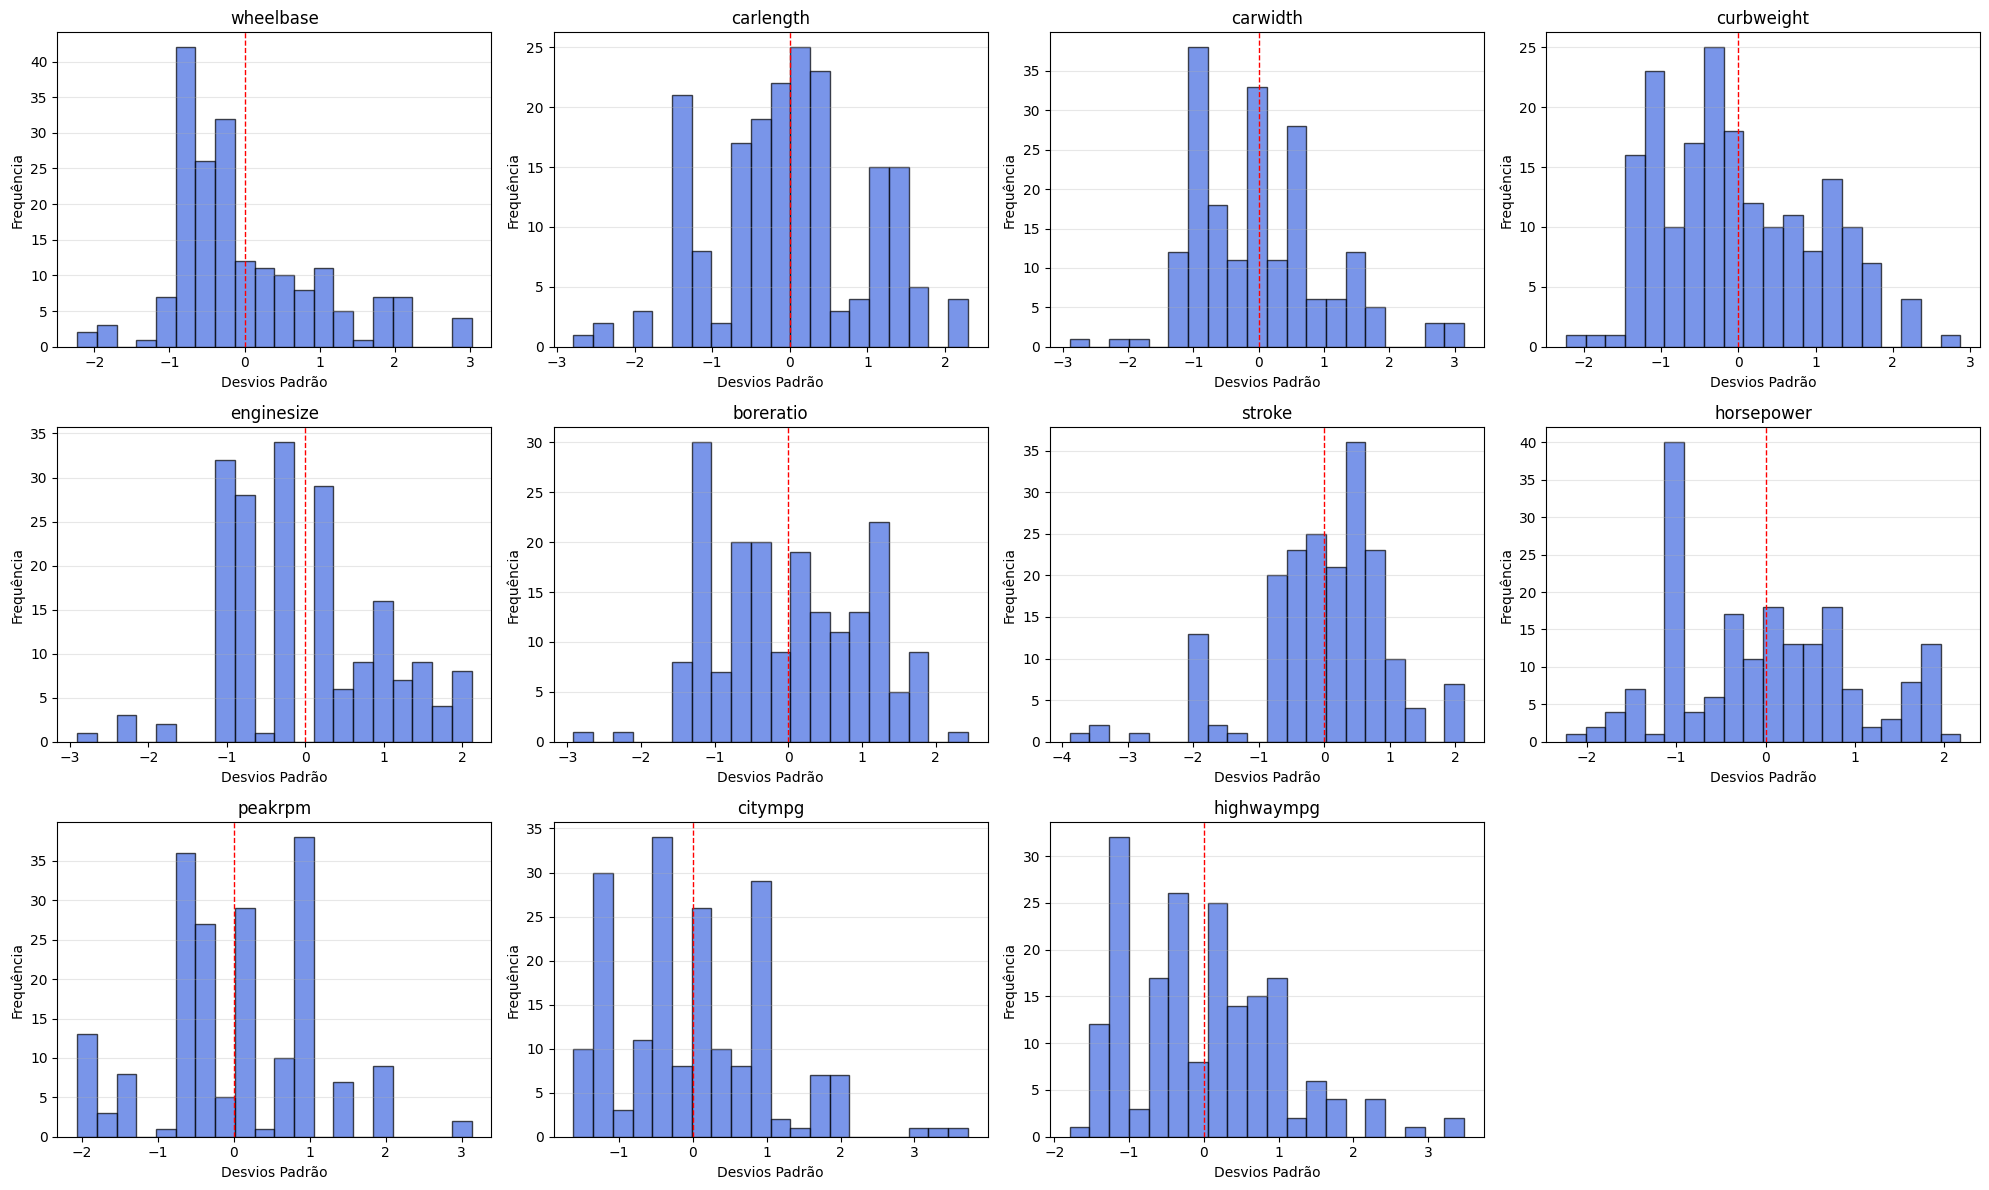

In [ ]:
# criar scaler
scaler = StandardScaler()

cols_to_scale = ['wheelbase', 'carlength', 'carwidth', 'curbweight', 
    'enginesize', 'boreratio', 'stroke', 'horsepower', 
    'peakrpm', 'citympg', 'highwaympg',
]

# Aplicando no DataFrame que já passou por Log e IQR
df_log[cols_to_scale] = scaler.fit_transform(df_log[cols_to_scale])

# 3. Visualizar com Matplotlib Puro
plt.figure(figsize=(20, 12))

for i, col in enumerate(cols_to_scale):
    plt.subplot(3, 4, i+1)
    
    # CORREÇÃO: df_log em vez de df.log
    plt.hist(df_log[col], bins=20, color='royalblue', edgecolor='black', alpha=0.7)
    
    # Adiciona uma linha vermelha no zero para conferir a média
    plt.axvline(0, color='red', linestyle='dashed', linewidth=1)
    
    plt.title(f"{col}")
    plt.grid(axis='y', alpha=0.3)
    plt.xlabel("Desvios Padrão")
    plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

# Encoding

Nesta etapa foi utilizado o método `get_dummies()` para transformar variáveis categóricas em variáveis numéricas.

Modelos de Machine Learning trabalham melhor com dados numéricos, portanto foi necessário converter colunas contendo textos ou categorias em representações numéricas.

O método cria novas colunas binárias para cada categoria existente, indicando:
- 1 → presença da categoria;
- 0 → ausência da categoria.

Esse processo é conhecido como *One-Hot Encoding* e permite que o modelo interprete corretamente informações categóricas sem criar relações numéricas artificiais entre as categorias.

Antes de transformar as colunas de texto em booleneano, será verificado quantas colunas serão adicionadas

In [13]:
# 1. Lista de colunas categóricas do seu dataset de carros
colunas_categoricas = [
    'fueltype', 'aspiration', 'doornumber', 
    'carbody', 'drivewheel', 'enginetype', 
    'cylindernumber', 'fuelsystem'
]

total_novas_colunas = 0

print("--- Análise de Colunas Categóricas ---")

for col in colunas_categoricas:
    n_unicos = df_log[col].nunique()
    # No One-Hot Encoding com drop_first=True, adicionamos (n-1) colunas
    novas = n_unicos - 1
    total_novas_colunas += novas
    print(f"{col}: {n_unicos} valores únicos -> +{novas} colunas")

print("-" * 38)
print(f"Total de novas colunas estimadas: {total_novas_colunas}")
print(f"Total final de colunas no dataset: {len(df.columns) - len(colunas_categoricas) + total_novas_colunas}")

--- Análise de Colunas Categóricas ---
fueltype: 2 valores únicos -> +1 colunas
aspiration: 2 valores únicos -> +1 colunas
doornumber: 2 valores únicos -> +1 colunas
carbody: 5 valores únicos -> +4 colunas
drivewheel: 3 valores únicos -> +2 colunas
enginetype: 6 valores únicos -> +5 colunas
cylindernumber: 5 valores únicos -> +4 colunas
fuelsystem: 8 valores únicos -> +7 colunas
--------------------------------------
Total de novas colunas estimadas: 25
Total final de colunas no dataset: 41


Agora de fato será aplicado o metodo `getdummies()`

In [14]:
# Adicione 'brand' na lista de dummies
df_final = pd.get_dummies(df_log, columns=[
    'fueltype', 'aspiration', 'doornumber', 'carbody', 
    'drivewheel', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand'
], drop_first=True)

print(f"Formato final: {df_final.shape}")

Formato final: (189, 60)


In [15]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 60 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   symboling             189 non-null    int64  
 1   wheelbase             189 non-null    float64
 2   carlength             189 non-null    float64
 3   carwidth              189 non-null    float64
 4   carheight             189 non-null    float64
 5   curbweight            189 non-null    float64
 6   enginesize            189 non-null    float64
 7   boreratio             189 non-null    float64
 8   stroke                189 non-null    float64
 9   compressionratio      189 non-null    float64
 10  horsepower            189 non-null    float64
 11  peakrpm               189 non-null    float64
 12  citympg               189 non-null    float64
 13  highwaympg            189 non-null    float64
 14  price                 189 non-null    float64
 15  fueltype_gas          189 non-null

# Seleção de features

O dataset foi dividido em conjunto de treino e teste.

O conjunto de treino é utilizado para ensinar o modelo, enquanto o conjunto de teste é utilizado para avaliar sua capacidade de generalização em dados nunca vistos.

In [16]:
y = df_final['price']

# 2. As Features (x) são todas as colunas, exceto o preço
x = df_final.drop(columns=['price'])

print(f"X: {x.shape} demais colunas")
print(f"y: {y.shape} alvo: preço")

X: (189, 59) demais colunas
y: (189,) alvo: preço


# Split do dataset

Nesta etapa foi utilizada a função `train_test_split()` para dividir o dataset em conjuntos de treino e teste.
A divisão foi realizada da seguinte forma:

x → variáveis independentes (features);
y → variável target, ou seja, o valor que o modelo deve prever;
x_train → dados utilizados para treinar o modelo;
x_test → dados utilizados para testar o modelo;
y_train → valores reais correspondentes ao conjunto de treino;
y_test → valores reais correspondentes ao conjunto de teste.

O parâmetro test_size=0.2 define que:

80% dos dados serão usados para treinamento;
20% serão usados para teste.

Já o parâmetro random_state=42 garante que a divisão dos dados seja reproduzível, ou seja, os mesmos dados serão separados da mesma forma sempre que o código for executado.

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Treinamento do modelo

O modelo Random Forest Regressor foi escolhido por possuir boa capacidade de generalização e lidar bem com relações não lineares.

Além disso, o algoritmo é robusto contra overfitting em muitos cenários.

In [1]:
#Criando o modelo
arvores = RandomForestRegressor(n_estimators = 80, 
                                 max_depth = 5, 
                                 random_state = 42, 
                                 n_jobs = -1,
                                 min_samples_leaf=1)

# Treinando o modelo
arvores.fit(x_train, y_train)

# Gerando as previsões
previsao = arvores.predict(x_test)

NameError: name 'RandomForestRegressor' is not defined

In [ ]:
# Visualizando MSE
np.sqrt(mean_squared_error(y_test, previsao))

np.float64(0.13471419740029944)

As métricas de avaliação foram utilizadas para medir o desempenho do modelo.

Entre elas:
- MAE (Erro Absoluto Médio);
- RMSE (Raiz do Erro Quadrático Médio);
- R² (Coeficiente de Determinação).

Essas métricas indicam o quão próximas as previsões estão dos valores reais.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Como o y agora só tem Log, o expm1 vai funcionar perfeitamente
y_real_reais = np.expm1(y_test)
previsao_reais = np.expm1(previsao)

# 2. Cálculos em escala de dinheiro
rmse_reais = np.sqrt(mean_squared_error(y_real_reais, previsao_reais))
media_venda = y_real_reais.mean()
margem_final = (rmse_reais / media_venda) * 100

print("RELATÓRIO EM REAIS")
print(f"Preço Médio Real: R$ {media_venda:.2f}")
print(f"Erro Médio (RMSE): R$ {rmse_reais:.2f}")
print(f"Margem de Erro: {margem_final:.2f}%")
print(f"Precisão de Mercado: {100 - margem_final:.2f}%")

--- AGORA SIM: RELATÓRIO EM REAIS ---
Preço Médio Real: R$ 10428.23
Erro Médio (RMSE): R$ 1725.79
Margem de Erro: 16.55%
Precisão de Mercado: 83.45%


In [ ]:
import pandas as pd

# Criando a tabela de erros
analise_erro = pd.DataFrame({
    'Real': np.expm1(y_test), 
    'Previsto': np.expm1(previsao)
})
analise_erro['Erro_Absoluto'] = abs(analise_erro['Real'] - analise_erro['Previsto'])
analise_erro['Erro_Percentual'] = (analise_erro['Erro_Absoluto'] / analise_erro['Real']) * 100

# Mostrando os 5 maiores erros
print(analise_erro.sort_values(by='Erro_Percentual', ascending=False).head(5))

        Real      Previsto  Erro_Absoluto  Erro_Percentual
60   18344.0  12223.316514    6120.683486        33.366133
156  17669.0  12395.113264    5273.886736        29.848247
132   8013.0  10367.697779    2354.697779        29.385970
78    5499.0   7053.318493    1554.318493        28.265475
96   13200.0  16091.846288    2891.846288        21.907926


# Conclusão

O projeto demonstrou o processo completo de construção de um modelo de Machine Learning para previsão de preços de veículos.

Foram realizadas etapas de:
- análise exploratória;
- limpeza;
- transformação de dados;
- treinamento;
- avaliação.

Os resultados mostram que o modelo conseguiu aprender padrões relevantes do dataset e realizar previsões satisfatórias.